# LendingClub discrete-time hazard model project
# File: data/raw/accepted_2007_to_2018Q4.csv.gz
#
# Workflow:
# 1. Load and clean data
# 2. Define event and censoring
# 3. Create duration
# 4. Expand to loan-month panel
# 5. Train/valid/test split
# 6. Logistic hazard model
# 7. Random forest comparison
# 8. Cumulative PD
# 9. Expected loss / reserve / pricing summaries

In [135]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [136]:
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

accepted_path = RAW_DIR / "lendingclub" /"accepted_2007_to_2018Q4.csv.gz"

# Runtime controls
USE_SAMPLE = True          # set to False if you want the full dataset
SAMPLE_SIZE = 90000        # increase later if your machine can handle it
RANDOM_STATE = 42

In [137]:
df_raw = pd.read_csv(
    accepted_path,
    low_memory=False,
    compression="gzip"
)

print("Raw shape:", df_raw.shape)
print("First 20 columns:", df_raw.columns.tolist()[:20])

Raw shape: (2260701, 151)
First 20 columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc']


In [138]:
key_columns = [
    "id",
    "issue_d",
    "loan_status",
    "term",
    "loan_amnt",
    "installment",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_range_low",
    "fico_range_high",
    "earliest_cr_line",
    "last_pymnt_d",
    "last_credit_pull_d",
]

missing_cols = [c for c in key_columns if c not in df_raw.columns]
print("Missing columns:", missing_cols)

Missing columns: []


In [139]:
cols = [c for c in key_columns if c in df_raw.columns]
df = df_raw[cols].copy()

print("Working shape:", df.shape)
df.head()

Working shape: (2260701, 27)


,id,issue_d,loan_status,term,loan_amnt,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_range_low,fico_range_high,earliest_cr_line,last_pymnt_d,last_credit_pull_d
0,68407277,Dec-2015,Fully Paid,36 months,3600.0,123.03,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,1.0,7.0,0.0,2765.0,29.7,13.0,1.0,0.0,675.0,679.0,Aug-2003,Jan-2019,Mar-2019
1,68355089,Dec-2015,Fully Paid,36 months,24700.0,820.28,10+ years,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,4.0,22.0,0.0,21470.0,19.2,38.0,4.0,0.0,715.0,719.0,Dec-1999,Jun-2016,Mar-2019
2,68341763,Dec-2015,Fully Paid,60 months,20000.0,432.66,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,0.0,6.0,0.0,7869.0,56.2,18.0,5.0,0.0,695.0,699.0,Aug-2000,Jun-2017,Mar-2019
3,66310712,Dec-2015,Current,60 months,35000.0,829.90,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,NJ,17.06,0.0,0.0,13.0,0.0,7802.0,11.6,17.0,1.0,0.0,785.0,789.0,Sep-2008,Feb-2019,Mar-2019
4,68476807,Dec-2015,Fully Paid,60 months,10400.0,289.91,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,3.0,12.0,0.0,21929.0,64.5,35.0,6.0,0.0,695.0,699.0,Jun-1998,Jul-2016,Mar-2018


In [140]:
if USE_SAMPLE:
    df = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).copy()

print("Shape after optional sampling:", df.shape)

Shape after optional sampling: (90000, 27)


In [141]:
date_cols = ["issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d"]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], format="%b-%Y", errors="coerce")

df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

df["term_num"] = (
    df["term"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

df["credit_history_years"] = (
    (df["issue_d"] - df["earliest_cr_line"]).dt.days / 365.25
)

df[["issue_d", "loan_status", "term", "term_num", "fico_avg", "credit_history_years"]].head()

,issue_d,loan_status,term,term_num,fico_avg,credit_history_years
392949,2015-02-01,Current,60 months,60.0,737.0,33.336071
1273506,2014-05-01,Fully Paid,36 months,36.0,687.0,13.081451
324024,2015-04-01,Fully Paid,36 months,36.0,782.0,11.581109
2066630,2017-12-01,Fully Paid,36 months,36.0,742.0,12.501027
477199,2018-02-01,Current,60 months,60.0,717.0,18.590007


In [142]:
status_counts = df["loan_status"].value_counts(dropna=False)
status_counts

loan_status
Fully Paid                                             42747
Current                                                34986
Charged Off                                            10805
Late (31-120 days)                                       871
In Grace Period                                          333
Late (16-30 days)                                        173
Does not meet the credit policy. Status:Fully Paid        51
Does not meet the credit policy. Status:Charged Off       30
NaN                                                        4
Name: count, dtype: int64

In [143]:
# Basic event definition:
# event = 1 for default-like outcomes
# event = 0 otherwise

default_statuses = {
    "Charged Off",
    "Default",
}

df["event"] = df["loan_status"].isin(default_statuses).astype(int)

# Use last payment date if available; otherwise use last credit pull date
df["end_date"] = df["last_pymnt_d"]
mask_missing_end = df["end_date"].isna()
df.loc[mask_missing_end, "end_date"] = df.loc[mask_missing_end, "last_credit_pull_d"]

df[["loan_status", "event", "issue_d", "last_pymnt_d", "last_credit_pull_d", "end_date"]].head()

,loan_status,event,issue_d,last_pymnt_d,last_credit_pull_d,end_date
392949,Current,0,2015-02-01,2019-03-01,2019-03-01,2019-03-01
1273506,Fully Paid,0,2014-05-01,2017-06-01,2017-08-01,2017-06-01
324024,Fully Paid,0,2015-04-01,2017-03-01,2019-02-01,2017-03-01
2066630,Fully Paid,0,2017-12-01,2018-10-01,2018-10-01,2018-10-01
477199,Current,0,2018-02-01,2019-03-01,2019-03-01,2019-03-01


In [144]:
def month_diff(start, end):
    return (end.dt.year - start.dt.year) * 12 + (end.dt.month - start.dt.month)

df = df[df["issue_d"].notna()].copy()
df = df[df["end_date"].notna()].copy()

df["duration_months"] = month_diff(df["issue_d"], df["end_date"])
df["duration_months"] = df["duration_months"].clip(lower=1)

print(df.shape)
df[["id", "issue_d", "end_date", "duration_months", "event"]].head()

(89996, 33)


,id,issue_d,end_date,duration_months,event
392949,39651438,2015-02-01,2019-03-01,49,0
1273506,16411620,2014-05-01,2017-06-01,37,0
324024,45122316,2015-04-01,2017-03-01,23,0
2066630,125356772,2017-12-01,2018-10-01,10,0
477199,128490686,2018-02-01,2019-03-01,13,0


In [145]:
df = df[df["term_num"].isin([36, 60])].copy()
df = df[df["duration_months"] >= 1].copy()
df = df[df["fico_avg"].notna()].copy()

print("After cleaning/filtering:", df.shape)

After cleaning/filtering: (89996, 33)


In [146]:
print("Event rate:")
print(df["event"].value_counts(normalize=True))

print("\nLoan status counts:")
print(df["loan_status"].value_counts(dropna=False).head(20))

print("\nDuration summary:")
print(df["duration_months"].describe())

Event rate:
event
0    0.879939
1    0.120061
Name: proportion, dtype: float64

Loan status counts:
loan_status
Fully Paid                                             42747
Current                                                34986
Charged Off                                            10805
Late (31-120 days)                                       871
In Grace Period                                          333
Late (16-30 days)                                        173
Does not meet the credit policy. Status:Fully Paid        51
Does not meet the credit policy. Status:Charged Off       30
Name: count, dtype: int64

Duration summary:
count    89996.000000
mean        19.570559
std         12.397257
min          1.000000
25%          9.000000
50%         17.000000
75%         29.000000
max         94.000000
Name: duration_months, dtype: float64


In [147]:
loan_level_path = PROCESSED_DIR / "loan_level_survival_base.csv"
df.to_csv(loan_level_path, index=False)
print(f"Saved loan-level base to: {loan_level_path}")

Saved loan-level base to: data/processed/loan_level_survival_base.csv


In [148]:
static_cols = [
    "loan_amnt",
    "term_num",
    "installment",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
]

def expand_loan(row):
    n = int(row["duration_months"])
    event = int(row["event"])

    out = pd.DataFrame({
        "id": row["id"],
        "issue_d": row["issue_d"],
        "month_on_book": np.arange(1, n + 1),
        "duration_months": row["duration_months"],
        "event": row["event"],
    })

    out["hazard_target"] = 0
    if event == 1:
        out.loc[out["month_on_book"] == n, "hazard_target"] = 1

    for col in static_cols:
        out[col] = row[col]

    return out

In [149]:
panel_parts = []
for _, row in df.iterrows():
    panel_parts.append(expand_loan(row))

panel = pd.concat(panel_parts, ignore_index=True)

print("Panel shape:", panel.shape)
panel.head()

Panel shape: (1761272, 27)


,id,issue_d,month_on_book,duration_months,event,hazard_target,loan_amnt,term_num,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_avg,credit_history_years
0,39651438,2015-02-01,1,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071
1,39651438,2015-02-01,2,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071
2,39651438,2015-02-01,3,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071
3,39651438,2015-02-01,4,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071
4,39651438,2015-02-01,5,49,0,0,32000.0,60.0,687.65,10+ years,MORTGAGE,120000.0,Verified,debt_consolidation,CA,24.05,0.0,0.0,20.0,0.0,39687.0,57.8,42.0,2.0,0.0,737.0,33.336071


In [150]:
panel["mob_str"] = panel["month_on_book"].astype(str)
panel["fico_x_mob"] = panel["fico_avg"] * panel["month_on_book"]
panel["term_x_mob"] = panel["term_num"] * panel["month_on_book"]
panel["dti_x_mob"] = panel["dti"] * panel["month_on_book"]

In [151]:
# Cleaner time specification
panel["mob_6bin"] = pd.cut(
    panel["month_on_book"],
    bins=[0, 6, 12, 18, 24, 36, 60, 120],
    labels=["1_6", "7_12", "13_18", "19_24", "25_36", "37_60", "61_plus"]
)

panel["month_on_book_sq"] = panel["month_on_book"] ** 2

# optional vintage variable
panel["issue_year"] = panel["issue_d"].dt.year.astype(str)

In [152]:
panel_path = PROCESSED_DIR / "loan_month_panel.csv"
panel.to_csv(panel_path, index=False)
print(f"Saved panel to: {panel_path}")

Saved panel to: data/processed/loan_month_panel.csv


In [153]:
train_panel = panel[panel["issue_d"] < "2016-01-01"].copy()
valid_panel = panel[(panel["issue_d"] >= "2016-01-01") & (panel["issue_d"] < "2017-01-01")].copy()
test_panel  = panel[panel["issue_d"] >= "2017-01-01"].copy()

print("Train shape:", train_panel.shape)
print("Valid shape:", valid_panel.shape)
print("Test shape :", test_panel.shape)

Train shape: (932040, 34)
Valid shape: (391399, 34)
Test shape : (437833, 34)


In [154]:
target = "hazard_target"

numeric_features = [
    "loan_amnt",
    "term_num",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
    "fico_x_mob",
    "term_x_mob",
    "dti_x_mob",
]

categorical_features = [
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "mob_str",      # full month dummy
    "mob_6bin",     # can keep this too
]

In [155]:
X_train = train_panel[numeric_features + categorical_features]
y_train = train_panel[target]

X_valid = valid_panel[numeric_features + categorical_features]
y_valid = valid_panel[target]

X_test = test_panel[numeric_features + categorical_features]
y_test = test_panel[target]

print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(932040, 26) (932040,)
(391399, 26) (391399,)
(437833, 26) (437833,)


In [156]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

In [157]:
hazard_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

hazard_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [158]:
valid_pred_hazard = hazard_model.predict_proba(X_valid)[:, 1]
test_pred_hazard = hazard_model.predict_proba(X_test)[:, 1]

hazard_results = {
    "valid_roc_auc": roc_auc_score(y_valid, valid_pred_hazard),
    "valid_pr_auc": average_precision_score(y_valid, valid_pred_hazard),
    "test_roc_auc": roc_auc_score(y_test, test_pred_hazard),
    "test_pr_auc": average_precision_score(y_test, test_pred_hazard),
}

hazard_results

{'valid_roc_auc': 0.6644510998975379,
 'valid_pr_auc': 0.013513873187659108,
 'test_roc_auc': 0.6705443367805358,
 'test_pr_auc': 0.008341943712689478}

In [159]:
from sklearn.calibration import CalibratedClassifierCV

In [160]:
rf_base = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )),
])

rf_calibrated = CalibratedClassifierCV(
    estimator=rf_base,
    method="sigmoid",
    cv=3
)

rf_calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

In [161]:
valid_pred_rf = rf_calibrated.predict_proba(X_valid)[:, 1]
test_pred_rf = rf_calibrated.predict_proba(X_test)[:, 1]

rf_results = {
    "valid_roc_auc": roc_auc_score(y_valid, valid_pred_rf),
    "valid_pr_auc": average_precision_score(y_valid, valid_pred_rf),
    "test_roc_auc": roc_auc_score(y_test, test_pred_rf),
    "test_pr_auc": average_precision_score(y_test, test_pred_rf),
}

rf_results

{'valid_roc_auc': 0.6568373154296456,
 'valid_pr_auc': 0.012907198473836468,
 'test_roc_auc': 0.6652843789467573,
 'test_pr_auc': 0.008311529282920003}

In [162]:
results_df = pd.DataFrame([
    {
        "model": "logistic_hazard",
        **hazard_results
    },
    {
        "model": "random_forest",
        **rf_results
    }
])

results_df

,model,valid_roc_auc,valid_pr_auc,test_roc_auc,test_pr_auc
0,logistic_hazard,0.664451,0.013514,0.670544,0.008342
1,random_forest,0.656837,0.012907,0.665284,0.008312


In [163]:
test_scored = test_panel.copy()
test_scored["pred_hazard_logit"] = test_pred_hazard
test_scored["pred_hazard_rf"] = test_pred_rf

test_scored = test_scored.sort_values(["id", "month_on_book"]).copy()
test_scored.head()

,id,issue_d,month_on_book,duration_months,event,hazard_target,loan_amnt,term_num,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,fico_avg,credit_history_years,mob_str,fico_x_mob,term_x_mob,dti_x_mob,mob_6bin,month_on_book_sq,issue_year,pred_hazard_logit,pred_hazard_rf
214997,100001365,2017-03-01,1,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,1,662.0,36.0,25.3,1_6,1,2017,0.003000,0.002148
214998,100001365,2017-03-01,2,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,2,1324.0,72.0,50.6,1_6,4,2017,0.003259,0.002800
214999,100001365,2017-03-01,3,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,3,1986.0,108.0,75.9,1_6,9,2017,0.003778,0.003252
215000,100001365,2017-03-01,4,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,4,2648.0,144.0,101.2,1_6,16,2017,0.003747,0.003844
215001,100001365,2017-03-01,5,24,0,0,20000.0,36.0,683.46,10+ years,MORTGAGE,87000.0,Not Verified,debt_consolidation,MT,25.3,0.0,0.0,12.0,0.0,19262.0,79.3,19.0,1.0,0.0,662.0,12.495551,5,3310.0,180.0,126.5,1_6,25,2017,0.003997,0.004040


In [164]:
test_scored["survival_prob_logit"] = test_scored.groupby("id")["pred_hazard_logit"].transform(
    lambda x: (1 - x).cumprod()
)
test_scored["cum_pd_logit"] = 1 - test_scored["survival_prob_logit"]

test_scored["survival_prob_rf"] = test_scored.groupby("id")["pred_hazard_rf"].transform(
    lambda x: (1 - x).cumprod()
)
test_scored["cum_pd_rf"] = 1 - test_scored["survival_prob_rf"]

test_scored[[
    "id", "month_on_book", "pred_hazard_logit", "cum_pd_logit",
    "pred_hazard_rf", "cum_pd_rf"
]].head(20)

,id,month_on_book,pred_hazard_logit,cum_pd_logit,pred_hazard_rf,cum_pd_rf
214997,100001365,1,0.003000,0.003000,0.002148,0.002148
214998,100001365,2,0.003259,0.006249,0.002800,0.004942
214999,100001365,3,0.003778,0.010003,0.003252,0.008177
215000,100001365,4,0.003747,0.013713,0.003844,0.011990
215001,100001365,5,0.003997,0.017655,0.004040,0.015982
215002,100001365,6,0.004289,0.021869,0.004896,0.020800
215003,100001365,7,0.008148,0.029838,0.005884,0.026561
215004,100001365,8,0.008010,0.037609,0.006255,0.032650
215005,100001365,9,0.008212,0.045513,0.007328,0.039739
215006,100001365,10,0.008351,0.053484,0.008627,0.048024


In [165]:
pd_summary = (
    test_scored[test_scored["month_on_book"].isin([6, 12, 24, 36])]
    .groupby("month_on_book")
    .agg(
        avg_cum_pd_logit=("cum_pd_logit", "mean"),
        avg_cum_pd_rf=("cum_pd_rf", "mean"),
        loans=("id", "nunique"),
    )
    .reset_index()
)

pd_summary

,month_on_book,avg_cum_pd_logit,avg_cum_pd_rf,loans
0,6,0.018068,0.021156,29591
1,12,0.055819,0.056530,17202
2,24,0.134077,0.134438,2001


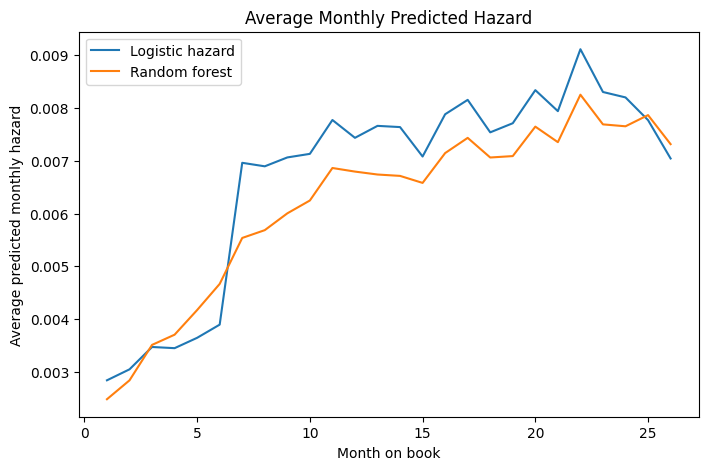

In [166]:
plot_hazard = (
    test_scored.groupby("month_on_book")[["pred_hazard_logit", "pred_hazard_rf"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(plot_hazard["month_on_book"], plot_hazard["pred_hazard_logit"], label="Logistic hazard")
plt.plot(plot_hazard["month_on_book"], plot_hazard["pred_hazard_rf"], label="Random forest")
plt.xlabel("Month on book")
plt.ylabel("Average predicted monthly hazard")
plt.title("Average Monthly Predicted Hazard")
plt.legend()
plt.show()

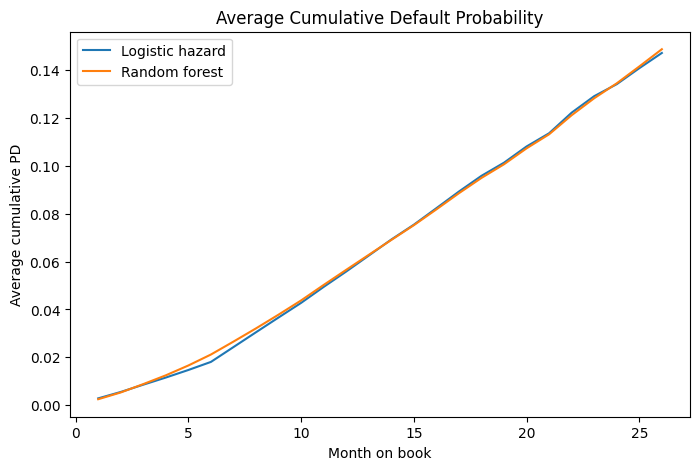

In [167]:
plot_cum_pd = (
    test_scored.groupby("month_on_book")[["cum_pd_logit", "cum_pd_rf"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(plot_cum_pd["month_on_book"], plot_cum_pd["cum_pd_logit"], label="Logistic hazard")
plt.plot(plot_cum_pd["month_on_book"], plot_cum_pd["cum_pd_rf"], label="Random forest")
plt.xlabel("Month on book")
plt.ylabel("Average cumulative PD")
plt.title("Average Cumulative Default Probability")
plt.legend()
plt.show()

In [168]:
loan_12m = test_scored[test_scored["month_on_book"] == 12].copy()

print("Loans with 12-month horizon rows:", loan_12m["id"].nunique())
loan_12m[["id", "cum_pd_logit", "cum_pd_rf"]].head()

Loans with 12-month horizon rows: 17202


,id,cum_pd_logit,cum_pd_rf
215008,100001365,0.070674,0.068491
539498,100001532,0.024204,0.039324
1473383,100001557,0.066775,0.071528
62778,100002096,0.060935,0.058785
1746963,100002651,0.096748,0.065673


In [169]:
LGD = 0.60

loan_12m["ead_proxy"] = loan_12m["loan_amnt"]
loan_12m["expected_loss_12m_logit"] = loan_12m["cum_pd_logit"] * LGD * loan_12m["ead_proxy"]
loan_12m["expected_loss_12m_rf"] = loan_12m["cum_pd_rf"] * LGD * loan_12m["ead_proxy"]

loan_12m[[
    "id",
    "loan_amnt",
    "cum_pd_logit",
    "cum_pd_rf",
    "expected_loss_12m_logit",
    "expected_loss_12m_rf"
]].head()

,id,loan_amnt,cum_pd_logit,cum_pd_rf,expected_loss_12m_logit,expected_loss_12m_rf
215008,100001365,20000.0,0.070674,0.068491,848.084448,821.894501
539498,100001532,30000.0,0.024204,0.039324,435.663889,707.838201
1473383,100001557,28000.0,0.066775,0.071528,1121.819319,1201.665842
62778,100002096,20000.0,0.060935,0.058785,731.223079,705.425546
1746963,100002651,10000.0,0.096748,0.065673,580.488633,394.039128


In [170]:
funding_cost = 0.04
profit_margin = 0.03

loan_12m["el_rate_12m_logit"] = loan_12m["expected_loss_12m_logit"] / loan_12m["loan_amnt"]
loan_12m["el_rate_12m_rf"] = loan_12m["expected_loss_12m_rf"] / loan_12m["loan_amnt"]

loan_12m["required_rate_logit"] = funding_cost + profit_margin + loan_12m["el_rate_12m_logit"]
loan_12m["required_rate_rf"] = funding_cost + profit_margin + loan_12m["el_rate_12m_rf"]

loan_12m[[
    "id",
    "required_rate_logit",
    "required_rate_rf"
]].head()

,id,required_rate_logit,required_rate_rf
215008,100001365,0.112404,0.111095
539498,100001532,0.084522,0.093595
1473383,100001557,0.110065,0.112917
62778,100002096,0.106561,0.105271
1746963,100002651,0.128049,0.109404


In [171]:
loan_12m["risk_band_logit"] = pd.qcut(
    loan_12m["cum_pd_logit"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

reserve_summary_logit = (
    loan_12m.groupby("risk_band_logit")
    .agg(
        loans=("id", "count"),
        avg_pd_12m=("cum_pd_logit", "mean"),
        total_expected_loss=("expected_loss_12m_logit", "sum"),
        avg_required_rate=("required_rate_logit", "mean"),
    )
    .reset_index()
)

reserve_summary_logit

,risk_band_logit,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,3441,0.021078,6.062887e+05,0.082647
1,Low,3440,0.036170,1.043388e+06,0.091702
2,Medium,3440,0.048616,1.456756e+06,0.099170
3,High,3440,0.064421,2.025379e+06,0.108653
4,Very High,3441,0.108806,4.177691e+06,0.135283


In [172]:
loan_12m["risk_band_rf"] = pd.qcut(
    loan_12m["cum_pd_rf"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

reserve_summary_rf = (
    loan_12m.groupby("risk_band_rf")
    .agg(
        loans=("id", "count"),
        avg_pd_12m=("cum_pd_rf", "mean"),
        total_expected_loss=("expected_loss_12m_rf", "sum"),
        avg_required_rate=("required_rate_rf", "mean"),
    )
    .reset_index()
)

reserve_summary_rf

,risk_band_rf,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,3441,0.033973,9.751707e+05,0.090384
1,Low,3440,0.043509,1.288540e+06,0.096106
2,Medium,3440,0.052378,1.587341e+06,0.101427
3,High,3440,0.063665,2.000444e+06,0.108199
4,Very High,3441,0.089123,3.303155e+06,0.123474


In [173]:
test_scored_path = PROCESSED_DIR / "test_panel_scored.csv"
loan_12m_path = PROCESSED_DIR / "loan_level_12m_outputs.csv"
results_path = PROCESSED_DIR / "model_comparison_results.csv"

test_scored.to_csv(test_scored_path, index=False)
loan_12m.to_csv(loan_12m_path, index=False)
results_df.to_csv(results_path, index=False)

print(f"Saved scored panel to: {test_scored_path}")
print(f"Saved 12m loan outputs to: {loan_12m_path}")
print(f"Saved model comparison to: {results_path}")

Saved scored panel to: data/processed/test_panel_scored.csv
Saved 12m loan outputs to: data/processed/loan_level_12m_outputs.csv
Saved model comparison to: data/processed/model_comparison_results.csv


In [174]:
print("Model comparison:")
display(results_df)

print("\n12-month cumulative PD summary:")
display(pd_summary)

print("\nReserve summary (logistic hazard):")
display(reserve_summary_logit)

Model comparison:


,model,valid_roc_auc,valid_pr_auc,test_roc_auc,test_pr_auc
0,logistic_hazard,0.664451,0.013514,0.670544,0.008342
1,random_forest,0.656837,0.012907,0.665284,0.008312



12-month cumulative PD summary:


,month_on_book,avg_cum_pd_logit,avg_cum_pd_rf,loans
0,6,0.018068,0.021156,29591
1,12,0.055819,0.056530,17202
2,24,0.134077,0.134438,2001



Reserve summary (logistic hazard):


,risk_band_logit,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,3441,0.021078,6.062887e+05,0.082647
1,Low,3440,0.036170,1.043388e+06,0.091702
2,Medium,3440,0.048616,1.456756e+06,0.099170
3,High,3440,0.064421,2.025379e+06,0.108653
4,Very High,3441,0.108806,4.177691e+06,0.135283


In [175]:
loan_12m["risk_band_rf"] = pd.qcut(
    loan_12m["cum_pd_rf"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

reserve_summary_rf = (
    loan_12m.groupby("risk_band_rf")
    .agg(
        loans=("id", "count"),
        avg_pd_12m=("cum_pd_rf", "mean"),
        total_expected_loss=("expected_loss_12m_rf", "sum"),
        avg_required_rate=("required_rate_rf", "mean"),
    )
    .reset_index()
)

reserve_summary_rf

,risk_band_rf,loans,avg_pd_12m,total_expected_loss,avg_required_rate
0,Very Low,3441,0.033973,9.751707e+05,0.090384
1,Low,3440,0.043509,1.288540e+06,0.096106
2,Medium,3440,0.052378,1.587341e+06,0.101427
3,High,3440,0.063665,2.000444e+06,0.108199
4,Very High,3441,0.089123,3.303155e+06,0.123474


# Looking at test

In [176]:
test_loans = df[df["issue_d"] >= "2017-01-01"].copy()

loan_obs = test_loans[["id", "duration_months", "event"]].drop_duplicates().copy()

print(loan_obs.shape)
loan_obs.head()

(37407, 3)


,id,duration_months,event
2066630,125356772,10,0
477199,128490686,13,0
641990,109655666,14,0
507598,127049010,14,0
2129008,121746633,17,0


In [177]:
max_mob = int(test_scored["month_on_book"].max())
months = np.arange(1, max_mob + 1)

n_loans = loan_obs["id"].nunique()

observed_curve = pd.DataFrame({"month_on_book": months})

observed_curve["observed_cum_pd"] = [
    ((loan_obs["event"] == 1) & (loan_obs["duration_months"] <= m)).sum() / n_loans
    for m in months
]

observed_curve.head(15)

,month_on_book,observed_cum_pd
0,1,0.001845
1,2,0.004251
2,3,0.007031
3,4,0.010934
4,5,0.014890
5,6,0.018820
6,7,0.022696
7,8,0.026439
8,9,0.029914
9,10,0.033336


In [178]:
plot_cum_pd = (
    test_scored.groupby("month_on_book")[["cum_pd_logit", "cum_pd_rf"]]
    .mean()
    .reset_index()
)

In [179]:
compare_curve = observed_curve.merge(
    plot_cum_pd,
    on="month_on_book",
    how="inner"
)

compare_curve.head()

,month_on_book,observed_cum_pd,cum_pd_logit,cum_pd_rf
0,1,0.001845,0.002840,0.002482
1,2,0.004251,0.005515,0.005312
2,3,0.007031,0.008556,0.008801
3,4,0.010934,0.011540,0.012466
4,5,0.014890,0.014696,0.016579


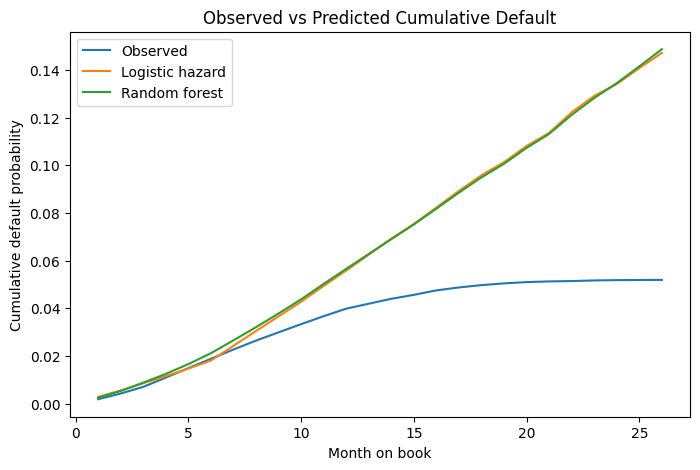

In [180]:
plt.figure(figsize=(8, 5))
plt.plot(compare_curve["month_on_book"], compare_curve["observed_cum_pd"], label="Observed")
plt.plot(compare_curve["month_on_book"], compare_curve["cum_pd_logit"], label="Logistic hazard")
plt.plot(compare_curve["month_on_book"], compare_curve["cum_pd_rf"], label="Random forest")
plt.xlabel("Month on book")
plt.ylabel("Cumulative default probability")
plt.title("Observed vs Predicted Cumulative Default")
plt.legend()
plt.show()

In [181]:
milestones = [6, 12, 18, 24]

calibration_table = compare_curve[
    compare_curve["month_on_book"].isin(milestones)
].copy()

calibration_table["logit_error"] = (
    calibration_table["cum_pd_logit"] - calibration_table["observed_cum_pd"]
)

calibration_table["rf_error"] = (
    calibration_table["cum_pd_rf"] - calibration_table["observed_cum_pd"]
)

calibration_table

,month_on_book,observed_cum_pd,cum_pd_logit,cum_pd_rf,logit_error,rf_error
5,6,0.018820,0.018068,0.021156,-0.000752,0.002336
11,12,0.039832,0.055819,0.056530,0.015987,0.016698
17,18,0.049723,0.095799,0.094925,0.046075,0.045201
23,24,0.051808,0.134077,0.134438,0.082268,0.082629


Loan-level test sample shape: (37407, 3)
                id  duration_months  event
2066630  125356772               10      0
477199   128490686               13      0
641990   109655666               14      0
507598   127049010               14      0
2129008  121746633               17      0

Kaplan-Meier curve:
    month_on_book  survival_prob  observed_cum_pd_km
0             0.0       1.000000            0.000000
1             1.0       0.998155            0.001845
2             2.0       0.995704            0.004296
3             3.0       0.992835            0.007165
4             4.0       0.988582            0.011418
5             5.0       0.983980            0.016020
6             6.0       0.979092            0.020908
7             7.0       0.973916            0.026084
8             8.0       0.968488            0.031512
9             9.0       0.963048            0.036952
10           10.0       0.957203            0.042797
11           11.0       0.950921            

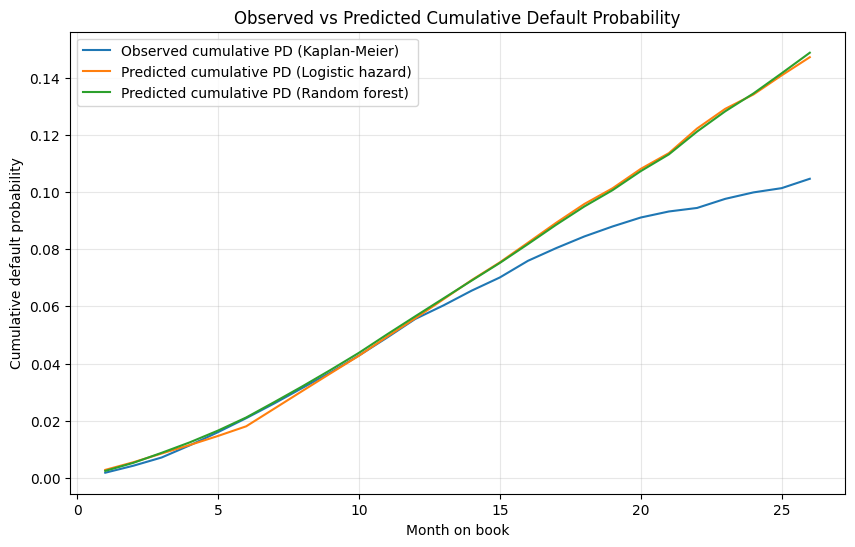


Calibration table:
    month_on_book  observed_cum_pd_km  cum_pd_logit  cum_pd_rf  logit_error  \
5               6            0.020908      0.018068   0.021156    -0.002840   
11             12            0.055602      0.055819   0.056530     0.000217   
17             18            0.084446      0.095799   0.094925     0.011353   
23             24            0.099847      0.134077   0.134438     0.034230   

    rf_error  
5   0.000247  
11  0.000928  
17  0.010479  
23  0.034591  


In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# =========================================================
# 1. Build loan-level TEST set for Kaplan-Meier
# =========================================================

# Make sure issue_d is datetime
df["issue_d"] = pd.to_datetime(df["issue_d"], errors="coerce")

# Match your test split
test_loans = df[df["issue_d"] >= "2017-01-01"].copy()

# Keep one row per loan with survival inputs
loan_obs = (
    test_loans[["id", "duration_months", "event"]]
    .drop_duplicates(subset=["id"])
    .copy()
)

# Clean types
loan_obs["duration_months"] = pd.to_numeric(loan_obs["duration_months"], errors="coerce")
loan_obs["event"] = pd.to_numeric(loan_obs["event"], errors="coerce")

# Drop bad rows if any
loan_obs = loan_obs.dropna(subset=["id", "duration_months", "event"]).copy()

# Optional: force valid ranges/types
loan_obs["duration_months"] = loan_obs["duration_months"].astype(int)
loan_obs["event"] = loan_obs["event"].astype(int)

print("Loan-level test sample shape:", loan_obs.shape)
print(loan_obs.head())


# =========================================================
# 2. Fit Kaplan-Meier on observed test-loan outcomes
# =========================================================

kmf = KaplanMeierFitter()

kmf.fit(
    durations=loan_obs["duration_months"],
    event_observed=loan_obs["event"],
    label="Kaplan-Meier survival"
)

# Convert survival curve to cumulative default curve
km_curve = kmf.survival_function_.reset_index()
km_curve.columns = ["month_on_book", "survival_prob"]
km_curve["observed_cum_pd_km"] = 1 - km_curve["survival_prob"]

print("\nKaplan-Meier curve:")
print(km_curve.head(15))


# =========================================================
# 3. Build average model-predicted cumulative PD curve
# =========================================================

plot_cum_pd = (
    test_scored.groupby("month_on_book")[["cum_pd_logit", "cum_pd_rf"]]
    .mean()
    .reset_index()
    .sort_values("month_on_book")
)

print("\nPredicted cumulative PD curve:")
print(plot_cum_pd.head(15))


# =========================================================
# 4. Merge KM observed curve with model curves
# =========================================================

compare_curve = pd.merge(
    plot_cum_pd,
    km_curve[["month_on_book", "observed_cum_pd_km"]],
    on="month_on_book",
    how="left"
).sort_values("month_on_book")

print("\nMerged comparison curve:")
print(compare_curve.head(15))


# =========================================================
# 5. Plot observed KM cumulative default vs predicted curves
# =========================================================

plt.figure(figsize=(10, 6))
plt.plot(
    compare_curve["month_on_book"],
    compare_curve["observed_cum_pd_km"],
    label="Observed cumulative PD (Kaplan-Meier)"
)
plt.plot(
    compare_curve["month_on_book"],
    compare_curve["cum_pd_logit"],
    label="Predicted cumulative PD (Logistic hazard)"
)
plt.plot(
    compare_curve["month_on_book"],
    compare_curve["cum_pd_rf"],
    label="Predicted cumulative PD (Random forest)"
)

plt.xlabel("Month on book")
plt.ylabel("Cumulative default probability")
plt.title("Observed vs Predicted Cumulative Default Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# =========================================================
# 6. Optional: milestone calibration table
# =========================================================

milestones = [6, 12, 18, 24]

calibration_table = (
    compare_curve[compare_curve["month_on_book"].isin(milestones)]
    .copy()
)

calibration_table["logit_error"] = (
    calibration_table["cum_pd_logit"] - calibration_table["observed_cum_pd_km"]
)

calibration_table["rf_error"] = (
    calibration_table["cum_pd_rf"] - calibration_table["observed_cum_pd_km"]
)

print("\nCalibration table:")
print(calibration_table[[
    "month_on_book",
    "observed_cum_pd_km",
    "cum_pd_logit",
    "cum_pd_rf",
    "logit_error",
    "rf_error"
]])

# Proportional Hazard??

In [183]:
# =========================
# Cox PH model: clean, loan-level setup
# =========================

import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

cox_num_features = [
    "loan_amnt",
    "term_num",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "revol_util",
    "fico_avg",
]

cox_cat_features = [
    "verification_status",
    "purpose",
    "home_ownership",
]

required_cols = ["duration_months", "event", "issue_d"] + cox_num_features + cox_cat_features

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in df: {missing_cols}")

loan_df = df[required_cols].copy()

# 1) Basic cleaning
loan_df["issue_d"] = pd.to_datetime(loan_df["issue_d"], errors="coerce")
loan_df["duration_months"] = pd.to_numeric(loan_df["duration_months"], errors="coerce")
loan_df["event"] = pd.to_numeric(loan_df["event"], errors="coerce")

for col in cox_num_features:
    loan_df[col] = pd.to_numeric(loan_df[col], errors="coerce")

loan_df = loan_df.dropna(subset=["issue_d", "duration_months", "event"]).copy()
loan_df = loan_df[loan_df["duration_months"] > 0].copy()

# 2) Train / valid / test split at loan level
train_loans = loan_df[loan_df["issue_d"] < "2016-01-01"].copy()
valid_loans = loan_df[(loan_df["issue_d"] >= "2016-01-01") & (loan_df["issue_d"] < "2017-01-01")].copy()
test_loans  = loan_df[loan_df["issue_d"] >= "2017-01-01"].copy()

print("Loan-level shapes before dummy encoding:")
print("Train:", train_loans.shape)
print("Valid:", valid_loans.shape)
print("Test :", test_loans.shape)

# 3) One-hot encode categoricals with drop_first=True
def make_cox_matrix(x, cat_cols):
    out = pd.get_dummies(x, columns=cat_cols, drop_first=True)
    bool_cols = out.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        out[bool_cols] = out[bool_cols].astype(int)
    return out

train_cox = make_cox_matrix(train_loans.drop(columns=["issue_d"]), cox_cat_features)
valid_cox = make_cox_matrix(valid_loans.drop(columns=["issue_d"]), cox_cat_features)
test_cox  = make_cox_matrix(test_loans.drop(columns=["issue_d"]), cox_cat_features)

# 4) Align columns across splits
feature_cols_train = [c for c in train_cox.columns if c not in ["duration_months", "event"]]

valid_cox = valid_cox.reindex(columns=["duration_months", "event"] + feature_cols_train, fill_value=0)
test_cox  = test_cox.reindex(columns=["duration_months", "event"] + feature_cols_train, fill_value=0)

# 5) Remove constant columns from training data
constant_cols = [c for c in feature_cols_train if train_cox[c].nunique(dropna=False) <= 1]
if constant_cols:
    train_cox = train_cox.drop(columns=constant_cols)
    valid_cox = valid_cox.drop(columns=constant_cols, errors="ignore")
    test_cox  = test_cox.drop(columns=constant_cols, errors="ignore")

feature_cols = [c for c in train_cox.columns if c not in ["duration_months", "event"]]

# 6) Check NaNs and drop incomplete rows
nan_counts = train_cox[["duration_months", "event"] + feature_cols].isna().sum()
nan_counts = nan_counts[nan_counts > 0]

if len(nan_counts) > 0:
    print("\nColumns with NaNs in training data:")
    print(nan_counts.sort_values(ascending=False))

train_cox = train_cox.dropna(subset=["duration_months", "event"] + feature_cols).copy()
valid_cox = valid_cox.dropna(subset=["duration_months", "event"] + feature_cols).copy()
test_cox  = test_cox.dropna(subset=["duration_months", "event"] + feature_cols).copy()

print("\nLoan-level shapes after dropping NaNs:")
print("Train:", train_cox.shape)
print("Valid:", valid_cox.shape)
print("Test :", test_cox.shape)

# 7) Fit Cox PH with penalization
cph = CoxPHFitter(penalizer=0.1)
cph.fit(
    train_cox[["duration_months", "event"] + feature_cols],
    duration_col="duration_months",
    event_col="event",
    show_progress=False,
)

print("\nCox model fit complete.")
print("Number of features used:", len(feature_cols))

# 8) Evaluate with concordance index
train_partial_hazard = cph.predict_partial_hazard(train_cox[feature_cols]).values.ravel()
valid_partial_hazard = cph.predict_partial_hazard(valid_cox[feature_cols]).values.ravel()
test_partial_hazard  = cph.predict_partial_hazard(test_cox[feature_cols]).values.ravel()

train_cindex = concordance_index(
    train_cox["duration_months"], -train_partial_hazard, train_cox["event"]
)
valid_cindex = concordance_index(
    valid_cox["duration_months"], -valid_partial_hazard, valid_cox["event"]
)
test_cindex = concordance_index(
    test_cox["duration_months"], -test_partial_hazard, test_cox["event"]
)

print("\nConcordance indices:")
print(f"Train C-index: {train_cindex:.4f}")
print(f"Valid C-index: {valid_cindex:.4f}")
print(f"Test  C-index: {test_cindex:.4f}")

# 9) Show coefficient summary
summary_cols = ["coef", "exp(coef)", "se(coef)", "p"]
available_summary_cols = [c for c in summary_cols if c in cph.summary.columns]

print("\nTop positive-risk features:")
display(cph.summary[available_summary_cols].sort_values("coef", ascending=False).head(15))

print("\nTop negative-risk features:")
display(cph.summary[available_summary_cols].sort_values("coef", ascending=True).head(15))

Loan-level shapes before dummy encoding:
Train: (35307, 14)
Valid: (17282, 14)
Test : (37407, 14)

Columns with NaNs in training data:
revol_util    15
dti            1
dtype: int64

Loan-level shapes after dropping NaNs:
Train: (35291, 29)
Valid: (17271, 29)
Test : (37305, 29)

Cox model fit complete.
Number of features used: 27

Concordance indices:
Train C-index: 0.6398
Valid C-index: 0.6369
Test  C-index: 0.6563

Top positive-risk features:


,coef,exp(coef),se(coef),p
covariate,,,,
home_ownership_NONE,1.530817,4.621953,0.605168,1.142005e-02
purpose_renewable_energy,0.387797,1.473731,0.445817,3.843779e-01
purpose_moving,0.311358,1.365278,0.130846,1.733260e-02
purpose_small_business,0.276367,1.318332,0.089690,2.060507e-03
purpose_medical,0.163190,1.177261,0.099770,1.019091e-01
home_ownership_RENT,0.143577,1.154396,0.021458,2.215458e-11
verification_status_Verified,0.136554,1.146317,0.023579,6.981845e-09
inq_last_6mths,0.116474,1.123528,0.009849,2.857451e-32
purpose_educational,0.096384,1.101182,0.596629,8.716620e-01



Top negative-risk features:


,coef,exp(coef),se(coef),p
covariate,,,,
home_ownership_OTHER,-0.819261,0.440757,8.863075e-01,3.553028e-01
purpose_wedding,-0.154392,0.856936,2.266581e-01,4.957654e-01
purpose_credit_card,-0.115797,0.890656,2.864385e-02,5.285244e-05
purpose_home_improvement,-0.029170,0.971251,4.869403e-02,5.491404e-01
fico_avg,-0.005582,0.994434,3.792156e-04,4.853111e-49
delinq_2yrs,-0.000519,0.999481,1.179691e-02,9.648758e-01
revol_util,-0.000263,0.999737,4.587116e-04,5.663093e-01
annual_inc,-0.000001,0.999999,2.266994e-07,1.520564e-10
loan_amnt,0.000005,1.000005,1.336761e-06,5.659258e-04


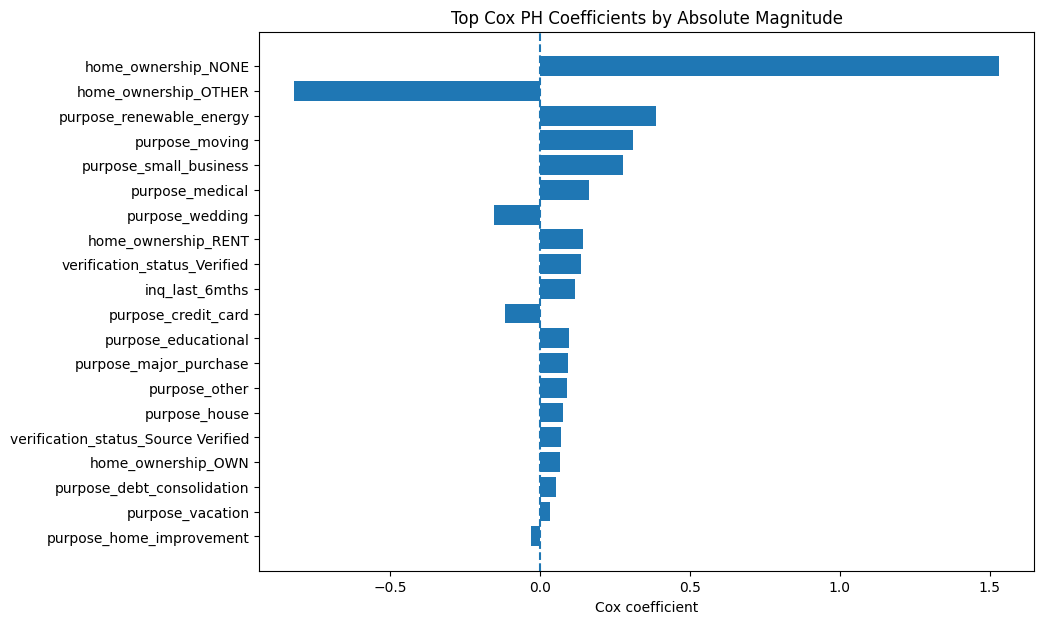

,coef,exp(coef),se(coef),p,feature,abs_coef
covariate,,,,,,
fico_avg,-0.005582,0.994434,3.792156e-04,4.853111e-49,fico_avg,0.005582
inq_last_6mths,0.116474,1.123528,9.848766e-03,2.857451e-32,inq_last_6mths,0.116474
term_num,0.009274,1.009317,9.508547e-04,1.794056e-22,term_num,0.009274
dti,0.010765,1.010824,1.243568e-03,4.847627e-18,dti,0.010765
home_ownership_RENT,0.143577,1.154396,2.145803e-02,2.215458e-11,home_ownership_RENT,0.143577
annual_inc,-0.000001,0.999999,2.266994e-07,1.520564e-10,annual_inc,0.000001
verification_status_Verified,0.136554,1.146317,2.357899e-02,6.981845e-09,verification_status_Verified,0.136554
purpose_credit_card,-0.115797,0.890656,2.864385e-02,5.285244e-05,purpose_credit_card,0.115797
loan_amnt,0.000005,1.000005,1.336761e-06,5.659258e-04,loan_amnt,0.000005


In [184]:
# =========================
# Cox coefficient charts
# =========================

cox_summary = cph.summary.copy()

# keep only the columns we care about
cols_keep = [c for c in ["coef", "exp(coef)", "se(coef)", "p"] if c in cox_summary.columns]
cox_summary = cox_summary[cols_keep].copy()
cox_summary["feature"] = cox_summary.index

# Sort by absolute effect size
cox_summary["abs_coef"] = cox_summary["coef"].abs()
cox_plot = cox_summary.sort_values("abs_coef", ascending=False).head(20).copy()

plt.figure(figsize=(10, 7))
plt.barh(cox_plot["feature"][::-1], cox_plot["coef"][::-1])
plt.axvline(0, linestyle="--")
plt.xlabel("Cox coefficient")
plt.title("Top Cox PH Coefficients by Absolute Magnitude")
plt.show()

display(cox_summary.sort_values("p").head(20))

In [185]:
# =========================
# Compare models
# =========================

comparison_rows = []

# Earlier results from your notebook if they still exist:
# hazard_results
# rf_results

if "hazard_results" in globals():
    comparison_rows.append({
        "model": "logistic_hazard_old",
        "valid_roc_auc": hazard_results.get("valid_roc_auc"),
        "valid_pr_auc": hazard_results.get("valid_pr_auc"),
        "test_roc_auc": hazard_results.get("test_roc_auc"),
        "test_pr_auc": hazard_results.get("test_pr_auc"),
        "valid_c_index": np.nan,
        "test_c_index": np.nan,
    })

if "rf_results" in globals():
    comparison_rows.append({
        "model": "random_forest_old",
        "valid_roc_auc": rf_results.get("valid_roc_auc"),
        "valid_pr_auc": rf_results.get("valid_pr_auc"),
        "test_roc_auc": rf_results.get("test_roc_auc"),
        "test_pr_auc": rf_results.get("test_pr_auc"),
        "valid_c_index": np.nan,
        "test_c_index": np.nan,
    })

comparison_rows.append({
    "model": "cox_ph_new",
    "valid_roc_auc": np.nan,
    "valid_pr_auc": np.nan,
    "test_roc_auc": np.nan,
    "test_pr_auc": np.nan,
    "valid_c_index": valid_cindex,
    "test_c_index": test_cindex,
})

model_compare_df = pd.DataFrame(comparison_rows)
display(model_compare_df)

,model,valid_roc_auc,valid_pr_auc,test_roc_auc,test_pr_auc,valid_c_index,test_c_index
0,logistic_hazard_old,0.664451,0.013514,0.670544,0.008342,NaN,NaN
1,random_forest_old,0.656837,0.012907,0.665284,0.008312,NaN,NaN
2,cox_ph_new,NaN,NaN,NaN,NaN,0.636881,0.65629


,cox_risk_band,loans,event_rate,avg_duration,avg_partial_hazard
0,Very Low,7461,0.016486,11.269267,0.580797
1,Low,7461,0.032435,11.470580,0.792375
2,Medium,7461,0.047581,11.778850,0.938601
3,High,7461,0.063530,12.080954,1.102321
4,Very High,7461,0.099585,11.945316,28.329924


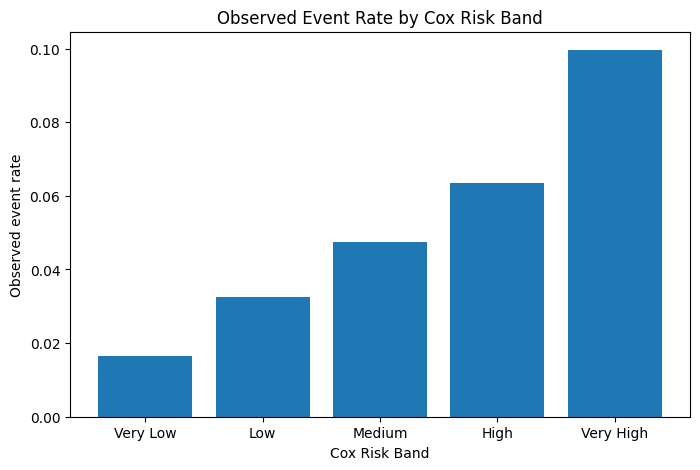

In [186]:
# =========================
# Cox risk bands on test set
# =========================

cox_test_scored = test_loans.copy()
cox_test_scored = cox_test_scored.loc[test_cox.index].copy()
cox_test_scored["cox_partial_hazard"] = test_partial_hazard

cox_test_scored["cox_risk_band"] = pd.qcut(
    cox_test_scored["cox_partial_hazard"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

cox_band_summary = (
    cox_test_scored.groupby("cox_risk_band")
    .agg(
        loans=("event", "count"),
        event_rate=("event", "mean"),
        avg_duration=("duration_months", "mean"),
        avg_partial_hazard=("cox_partial_hazard", "mean"),
    )
    .reset_index()
)

display(cox_band_summary)

plt.figure(figsize=(8, 5))
plt.bar(cox_band_summary["cox_risk_band"], cox_band_summary["event_rate"])
plt.xlabel("Cox Risk Band")
plt.ylabel("Observed event rate")
plt.title("Observed Event Rate by Cox Risk Band")
plt.show()

,month_on_book,cum_pd_logit,cum_pd_rf,observed_cum_pd_km,cum_pd_cox
0,1,0.002840,0.002482,0.001845,0.001443
1,2,0.005515,0.005312,0.004296,0.003462
2,3,0.008556,0.008801,0.007165,0.006765
3,4,0.011540,0.012466,0.011418,0.010028
4,5,0.014696,0.016579,0.016020,0.013889
5,6,0.018068,0.021156,0.020908,0.018417
6,7,0.024264,0.026554,0.026084,0.024304
7,8,0.030465,0.032077,0.031512,0.030007
8,9,0.036624,0.037812,0.036952,0.035965
9,10,0.042731,0.043751,0.042797,0.042097


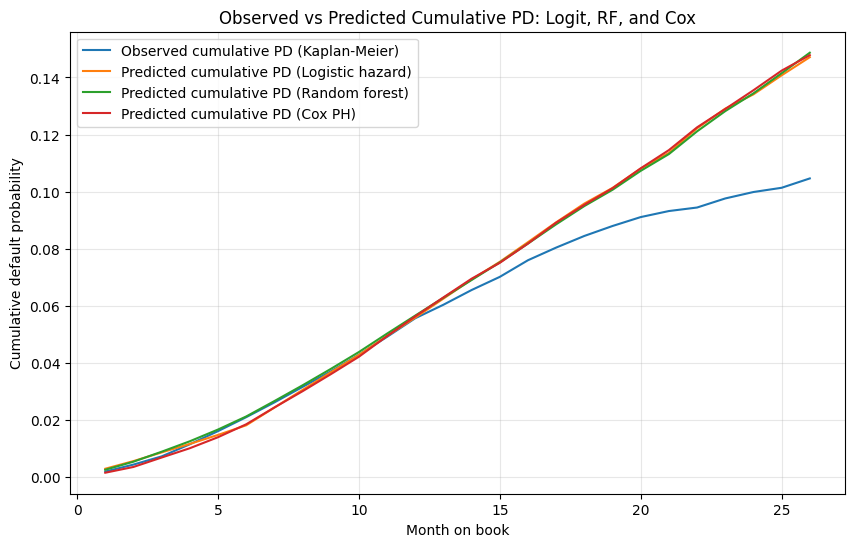

,month_on_book,observed_cum_pd_km,cum_pd_logit,cum_pd_rf,cum_pd_cox,logit_error,rf_error,cox_error
5,6,0.020908,0.018068,0.021156,0.018417,-0.002840,0.000247,-0.002491
11,12,0.055602,0.055819,0.056530,0.056270,0.000217,0.000928,0.000668
17,18,0.084446,0.095799,0.094925,0.095351,0.011353,0.010479,0.010905
23,24,0.099847,0.134077,0.134438,0.135520,0.034230,0.034591,0.035673


In [187]:
# =========================
# Cox cumulative PD over time vs prior models
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1) Build Cox predicted survival curves on test set
# -------------------------------------------------
# test_cox: encoded loan-level test matrix used in Cox
# feature_cols: Cox feature columns
# cph: fitted CoxPHFitter
# compare_curve: earlier dataframe with month_on_book, observed_cum_pd_km, cum_pd_logit, cum_pd_rf
# If compare_curve does not exist, this cell rebuilds it from your earlier objects.

# Predict survival functions for each test loan
cox_surv = cph.predict_survival_function(test_cox[feature_cols])

# cox_surv rows are times, columns are loans
# Convert to cumulative PD
cox_cum_pd = 1 - cox_surv

# Average across loans at each time
cox_curve = cox_cum_pd.mean(axis=1).reset_index()
cox_curve.columns = ["month_on_book", "cum_pd_cox"]

# lifelines may return float times like 1.0, 2.0, ...
cox_curve["month_on_book"] = cox_curve["month_on_book"].astype(float)

# -------------------------------------------------
# 2) Rebuild earlier comparison curve if needed
# -------------------------------------------------
if "compare_curve" not in globals():
    # observed KM cumulative PD
    from lifelines import KaplanMeierFitter

    loan_obs = (
        df.loc[df["issue_d"] >= "2017-01-01", ["id", "duration_months", "event"]]
        .drop_duplicates(subset=["id"])
        .copy()
    )
    loan_obs["duration_months"] = pd.to_numeric(loan_obs["duration_months"], errors="coerce")
    loan_obs["event"] = pd.to_numeric(loan_obs["event"], errors="coerce")
    loan_obs = loan_obs.dropna(subset=["duration_months", "event"]).copy()
    loan_obs["duration_months"] = loan_obs["duration_months"].astype(int)
    loan_obs["event"] = loan_obs["event"].astype(int)

    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=loan_obs["duration_months"],
        event_observed=loan_obs["event"],
        label="Kaplan-Meier survival"
    )

    km_curve = kmf.survival_function_.reset_index()
    km_curve.columns = ["month_on_book", "survival_prob"]
    km_curve["observed_cum_pd_km"] = 1 - km_curve["survival_prob"]

    # earlier logit/RF cumulative PD from panel test scores
    plot_cum_pd = (
        test_scored.groupby("month_on_book")[["cum_pd_logit", "cum_pd_rf"]]
        .mean()
        .reset_index()
        .sort_values("month_on_book")
    )

    compare_curve = pd.merge(
        plot_cum_pd,
        km_curve[["month_on_book", "observed_cum_pd_km"]],
        on="month_on_book",
        how="left"
    ).sort_values("month_on_book")

# -------------------------------------------------
# 3) Merge Cox curve with prior curves
# -------------------------------------------------
compare_curve_with_cox = pd.merge(
    compare_curve,
    cox_curve,
    on="month_on_book",
    how="left"
).sort_values("month_on_book")

display(compare_curve_with_cox.head(15))

# -------------------------------------------------
# 4) Plot all cumulative PD curves together
# -------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(
    compare_curve_with_cox["month_on_book"],
    compare_curve_with_cox["observed_cum_pd_km"],
    label="Observed cumulative PD (Kaplan-Meier)"
)
plt.plot(
    compare_curve_with_cox["month_on_book"],
    compare_curve_with_cox["cum_pd_logit"],
    label="Predicted cumulative PD (Logistic hazard)"
)
plt.plot(
    compare_curve_with_cox["month_on_book"],
    compare_curve_with_cox["cum_pd_rf"],
    label="Predicted cumulative PD (Random forest)"
)
plt.plot(
    compare_curve_with_cox["month_on_book"],
    compare_curve_with_cox["cum_pd_cox"],
    label="Predicted cumulative PD (Cox PH)"
)

plt.xlabel("Month on book")
plt.ylabel("Cumulative default probability")
plt.title("Observed vs Predicted Cumulative PD: Logit, RF, and Cox")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------------------------
# 5) Milestone calibration table including Cox
# -------------------------------------------------
milestones = [6, 12, 18, 24]

calibration_table_all = (
    compare_curve_with_cox[compare_curve_with_cox["month_on_book"].isin(milestones)]
    .copy()
)

calibration_table_all["logit_error"] = (
    calibration_table_all["cum_pd_logit"] - calibration_table_all["observed_cum_pd_km"]
)
calibration_table_all["rf_error"] = (
    calibration_table_all["cum_pd_rf"] - calibration_table_all["observed_cum_pd_km"]
)
calibration_table_all["cox_error"] = (
    calibration_table_all["cum_pd_cox"] - calibration_table_all["observed_cum_pd_km"]
)

display(
    calibration_table_all[
        [
            "month_on_book",
            "observed_cum_pd_km",
            "cum_pd_logit",
            "cum_pd_rf",
            "cum_pd_cox",
            "logit_error",
            "rf_error",
            "cox_error",
        ]
    ]
)

# Variable importance

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
)
from sklearn.inspection import permutation_importance

In [189]:
target = "hazard_target"

all_numeric_features = [
    "loan_amnt",
    "term_num",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc",
    "pub_rec_bankruptcies",
    "fico_avg",
    "credit_history_years",
    "fico_x_mob",
    "term_x_mob",
    "dti_x_mob",
]

all_categorical_features = [
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "mob_str",
    "mob_6bin",
]

# Group variables in a way that matches your reasoning
feature_groups = {
    "loan_size_terms": ["loan_amnt", "term_num", "installment"],
    "employment_home": ["emp_length", "home_ownership"],
    "income_verification": ["annual_inc", "verification_status"],
    "purpose_state": ["purpose", "addr_state"],
    "delinq_inquiry": ["delinq_2yrs", "inq_last_6mths"],
    "accounts_public": ["open_acc", "pub_rec", "pub_rec_bankruptcies"],
    "utilization_balance": ["revol_bal", "revol_util"],
    "capacity_depth": ["total_acc", "mort_acc", "credit_history_years"],
    "credit_quality": ["fico_avg", "dti"],
    "time_main": ["mob_str", "mob_6bin"],
    "time_interactions": ["fico_x_mob", "term_x_mob", "dti_x_mob"],
}

# Also test single raw features if you want finer simplification
single_feature_groups = {f: [f] for f in (all_numeric_features + all_categorical_features)}

In [190]:
def split_feature_types(features, numeric_pool, categorical_pool):
    num = [f for f in features if f in numeric_pool]
    cat = [f for f in features if f in categorical_pool]
    return num, cat


def make_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])
    return preprocessor


def make_logit_pipeline(numeric_features, categorical_features):
    preprocessor = make_preprocessor(numeric_features, categorical_features)
    model = Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000))
    ])
    return model


def make_rf_pipeline(numeric_features, categorical_features, random_state=42):
    preprocessor = make_preprocessor(numeric_features, categorical_features)

    rf_base = Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=50,
            random_state=random_state,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ])

    rf_calibrated = CalibratedClassifierCV(
        estimator=rf_base,
        method="sigmoid",
        cv=3
    )
    return rf_calibrated


def get_pred_proba(model, X):
    return model.predict_proba(X)[:, 1]


def compute_metrics(y_true, y_prob, eps=1e-12):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "logloss": log_loss(y_true, y_prob),
        "mean_pred": float(np.mean(y_prob)),
        "event_rate": float(np.mean(y_true)),
    }


def fit_and_score_model(
    model_type,
    features,
    X_train_full, y_train,
    X_valid_full, y_valid,
    X_test_full, y_test,
    numeric_pool,
    categorical_pool,
    random_state=42
):
    numeric_features, categorical_features = split_feature_types(
        features, numeric_pool, categorical_pool
    )

    X_train = X_train_full[features].copy()
    X_valid = X_valid_full[features].copy()
    X_test = X_test_full[features].copy()

    if model_type == "logit":
        model = make_logit_pipeline(numeric_features, categorical_features)
    elif model_type == "rf":
        model = make_rf_pipeline(numeric_features, categorical_features, random_state=random_state)
    else:
        raise ValueError("model_type must be 'logit' or 'rf'")

    model.fit(X_train, y_train)

    valid_prob = get_pred_proba(model, X_valid)
    test_prob = get_pred_proba(model, X_test)

    valid_metrics = compute_metrics(y_valid, valid_prob)
    test_metrics = compute_metrics(y_test, test_prob)

    out = {
        "model": model,
        "features": features,
        "n_features_raw": len(features),
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "valid_metrics": valid_metrics,
        "test_metrics": test_metrics,
        "valid_prob": valid_prob,
        "test_prob": test_prob,
    }
    return out

In [191]:
all_features = all_numeric_features + all_categorical_features

X_train_full = train_panel[all_features].copy()
y_train = train_panel[target].copy()

X_valid_full = valid_panel[all_features].copy()
y_valid = valid_panel[target].copy()

X_test_full = test_panel[all_features].copy()
y_test = test_panel[target].copy()

In [192]:
baseline_logit = fit_and_score_model(
    model_type="logit",
    features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

baseline_rf = fit_and_score_model(
    model_type="rf",
    features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

print("Baseline logit VALID:", baseline_logit["valid_metrics"])
print("Baseline logit TEST :", baseline_logit["test_metrics"])
print()
print("Baseline RF VALID   :", baseline_rf["valid_metrics"])
print("Baseline RF TEST    :", baseline_rf["test_metrics"])

Baseline logit VALID: {'roc_auc': 0.6644510998975379, 'pr_auc': 0.013513873187659108, 'brier': 0.006965209814027969, 'logloss': 0.0407007804409802, 'mean_pred': 0.0062547019512976, 'event_rate': 0.007015858497339033}
Baseline logit TEST : {'roc_auc': 0.6705443367805358, 'pr_auc': 0.008341943712689478, 'brier': 0.004787181172564742, 'logloss': 0.03100861445099916, 'mean_pred': 0.005523270804034634, 'event_rate': 0.004435481108093726}

Baseline RF VALID   : {'roc_auc': 0.6568373154296456, 'pr_auc': 0.012907198473836468, 'brier': 0.006951580357783106, 'logloss': 0.040753960036154176, 'mean_pred': 0.00624411401652934, 'event_rate': 0.007015858497339033}
Baseline RF TEST    : {'roc_auc': 0.6652843789467573, 'pr_auc': 0.008311529282920003, 'brier': 0.004409581096031979, 'logloss': 0.027774702969589348, 'mean_pred': 0.0051076744521263056, 'event_rate': 0.004435481108093726}


In [193]:
def run_group_removal_experiments(
    model_type,
    feature_groups,
    base_features,
    X_train_full, y_train,
    X_valid_full, y_valid,
    X_test_full, y_test,
    numeric_pool,
    categorical_pool,
    random_state=42
):
    baseline = fit_and_score_model(
        model_type=model_type,
        features=base_features,
        X_train_full=X_train_full, y_train=y_train,
        X_valid_full=X_valid_full, y_valid=y_valid,
        X_test_full=X_test_full, y_test=y_test,
        numeric_pool=numeric_pool,
        categorical_pool=categorical_pool,
        random_state=random_state
    )

    rows = []

    for group_name, remove_vars in feature_groups.items():
        reduced_features = [f for f in base_features if f not in remove_vars]

        result = fit_and_score_model(
            model_type=model_type,
            features=reduced_features,
            X_train_full=X_train_full, y_train=y_train,
            X_valid_full=X_valid_full, y_valid=y_valid,
            X_test_full=X_test_full, y_test=y_test,
            numeric_pool=numeric_pool,
            categorical_pool=categorical_pool,
            random_state=random_state
        )

        row = {
            "model_type": model_type,
            "removed_group": group_name,
            "removed_vars": ", ".join(remove_vars),
            "n_removed_raw": len(remove_vars),
            "n_features_remaining_raw": len(reduced_features),

            "baseline_valid_roc_auc": baseline["valid_metrics"]["roc_auc"],
            "baseline_valid_pr_auc": baseline["valid_metrics"]["pr_auc"],
            "baseline_valid_brier": baseline["valid_metrics"]["brier"],
            "baseline_valid_logloss": baseline["valid_metrics"]["logloss"],

            "reduced_valid_roc_auc": result["valid_metrics"]["roc_auc"],
            "reduced_valid_pr_auc": result["valid_metrics"]["pr_auc"],
            "reduced_valid_brier": result["valid_metrics"]["brier"],
            "reduced_valid_logloss": result["valid_metrics"]["logloss"],

            "delta_valid_roc_auc": result["valid_metrics"]["roc_auc"] - baseline["valid_metrics"]["roc_auc"],
            "delta_valid_pr_auc": result["valid_metrics"]["pr_auc"] - baseline["valid_metrics"]["pr_auc"],
            "delta_valid_brier": result["valid_metrics"]["brier"] - baseline["valid_metrics"]["brier"],
            "delta_valid_logloss": result["valid_metrics"]["logloss"] - baseline["valid_metrics"]["logloss"],

            "baseline_test_roc_auc": baseline["test_metrics"]["roc_auc"],
            "baseline_test_pr_auc": baseline["test_metrics"]["pr_auc"],
            "baseline_test_brier": baseline["test_metrics"]["brier"],
            "baseline_test_logloss": baseline["test_metrics"]["logloss"],

            "reduced_test_roc_auc": result["test_metrics"]["roc_auc"],
            "reduced_test_pr_auc": result["test_metrics"]["pr_auc"],
            "reduced_test_brier": result["test_metrics"]["brier"],
            "reduced_test_logloss": result["test_metrics"]["logloss"],

            "delta_test_roc_auc": result["test_metrics"]["roc_auc"] - baseline["test_metrics"]["roc_auc"],
            "delta_test_pr_auc": result["test_metrics"]["pr_auc"] - baseline["test_metrics"]["pr_auc"],
            "delta_test_brier": result["test_metrics"]["brier"] - baseline["test_metrics"]["brier"],
            "delta_test_logloss": result["test_metrics"]["logloss"] - baseline["test_metrics"]["logloss"],
        }
        rows.append(row)

    results_df = pd.DataFrame(rows).sort_values(
        ["delta_valid_pr_auc", "delta_valid_roc_auc"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return baseline, results_df

In [194]:
baseline_logit_grouped, grouped_logit_results = run_group_removal_experiments(
    model_type="logit",
    feature_groups=feature_groups,
    base_features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

baseline_rf_grouped, grouped_rf_results = run_group_removal_experiments(
    model_type="rf",
    feature_groups=feature_groups,
    base_features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

grouped_logit_results

KeyboardInterrupt: 

In [ ]:
def plot_group_removal(results_df, metric_col, title):
    plot_df = results_df.sort_values(metric_col, ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["removed_group"], plot_df[metric_col])
    plt.axvline(0, linestyle="--")
    plt.xlabel(metric_col)
    plt.title(title)
    plt.show()

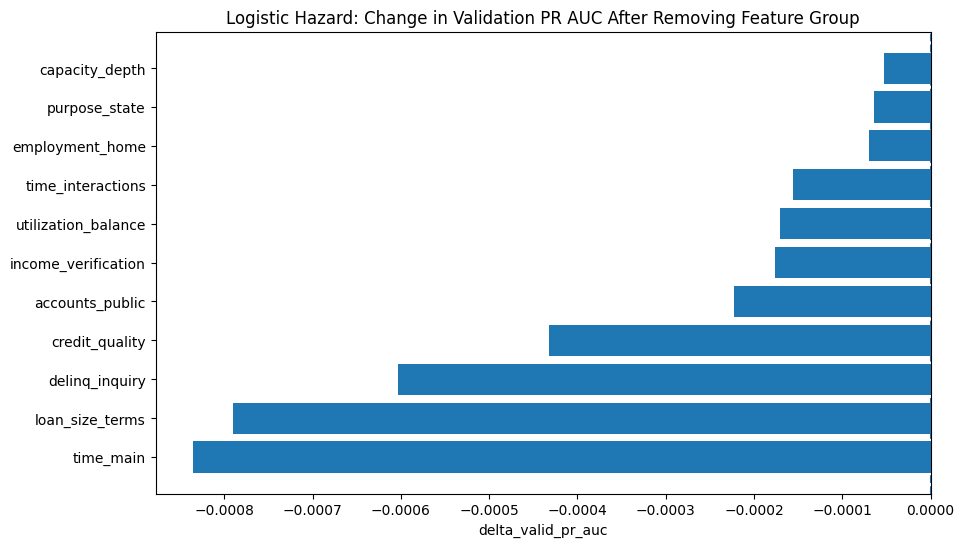

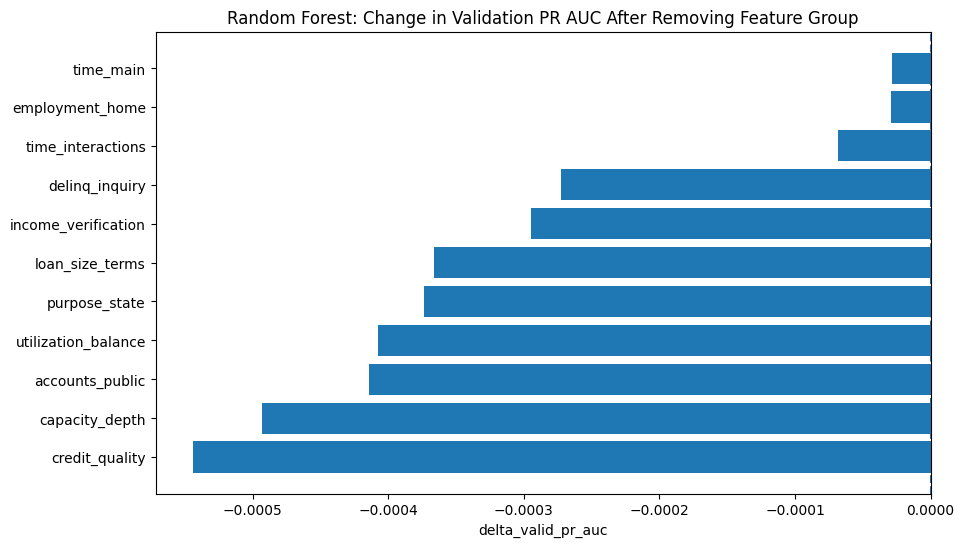

In [ ]:
plot_group_removal(
    grouped_logit_results,
    "delta_valid_pr_auc",
    "Logistic Hazard: Change in Validation PR AUC After Removing Feature Group"
)

plot_group_removal(
    grouped_rf_results,
    "delta_valid_pr_auc",
    "Random Forest: Change in Validation PR AUC After Removing Feature Group"
)

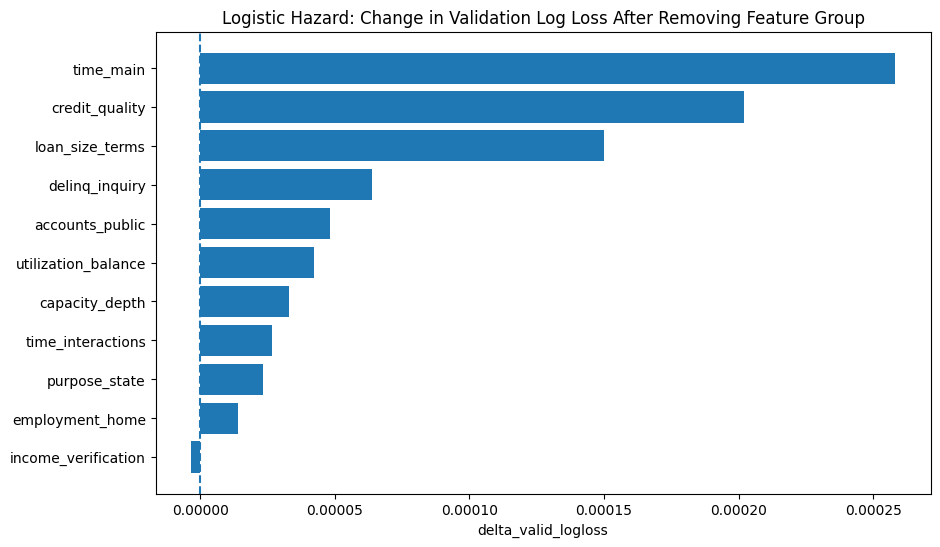

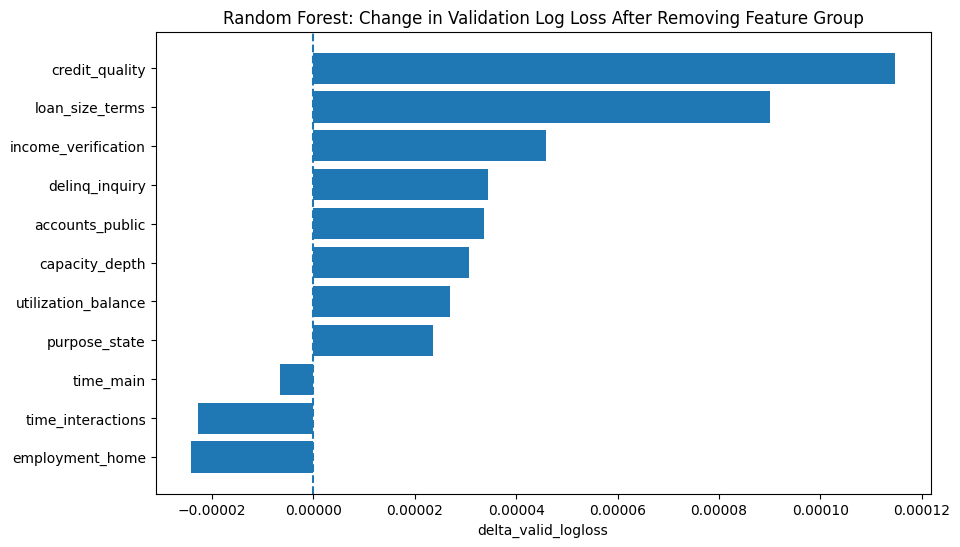

In [ ]:
plot_group_removal(
    grouped_logit_results,
    "delta_valid_logloss",
    "Logistic Hazard: Change in Validation Log Loss After Removing Feature Group"
)

plot_group_removal(
    grouped_rf_results,
    "delta_valid_logloss",
    "Random Forest: Change in Validation Log Loss After Removing Feature Group"
)

In [ ]:
baseline_logit_single, single_logit_results = run_group_removal_experiments(
    model_type="logit",
    feature_groups=single_feature_groups,
    base_features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

baseline_rf_single, single_rf_results = run_group_removal_experiments(
    model_type="rf",
    feature_groups=single_feature_groups,
    base_features=all_features,
    X_train_full=X_train_full, y_train=y_train,
    X_valid_full=X_valid_full, y_valid=y_valid,
    X_test_full=X_test_full, y_test=y_test,
    numeric_pool=all_numeric_features,
    categorical_pool=all_categorical_features,
)

single_logit_results.head(20)

,model_type,removed_group,removed_vars,n_removed_raw,n_features_remaining_raw,baseline_valid_roc_auc,baseline_valid_pr_auc,baseline_valid_brier,baseline_valid_logloss,reduced_valid_roc_auc,reduced_valid_pr_auc,reduced_valid_brier,reduced_valid_logloss,delta_valid_roc_auc,delta_valid_pr_auc,delta_valid_brier,delta_valid_logloss,baseline_test_roc_auc,baseline_test_pr_auc,baseline_test_brier,baseline_test_logloss,reduced_test_roc_auc,reduced_test_pr_auc,reduced_test_brier,reduced_test_logloss,delta_test_roc_auc,delta_test_pr_auc,delta_test_brier,delta_test_logloss
0,logit,mort_acc,mort_acc,1,25,0.668269,0.013058,0.006849,0.040077,0.669209,0.013136,0.006849,0.040072,0.000940,0.000078,-7.725289e-08,-0.000005,0.668531,0.010645,0.005765,0.035015,0.669944,0.010713,0.005770,0.035071,0.001414,0.000068,4.905618e-06,5.599137e-05
1,logit,pub_rec,pub_rec,1,25,0.668269,0.013058,0.006849,0.040077,0.668363,0.013084,0.006849,0.040073,0.000094,0.000027,-9.519762e-08,-0.000004,0.668531,0.010645,0.005765,0.035015,0.669152,0.010679,0.005766,0.035014,0.000622,0.000034,3.745275e-07,-3.471072e-07
2,logit,delinq_2yrs,delinq_2yrs,1,25,0.668269,0.013058,0.006849,0.040077,0.668246,0.013080,0.006849,0.040074,-0.000023,0.000023,-4.181435e-08,-0.000002,0.668531,0.010645,0.005765,0.035015,0.668670,0.010666,0.005764,0.034995,0.000139,0.000021,-7.654378e-07,-1.954630e-05
3,logit,open_acc,open_acc,1,25,0.668269,0.013058,0.006849,0.040077,0.669468,0.013046,0.006849,0.040061,0.001199,-0.000011,-9.749979e-08,-0.000015,0.668531,0.010645,0.005765,0.035015,0.673609,0.010828,0.005776,0.035105,0.005078,0.000183,1.131944e-05,9.016541e-05
4,logit,emp_length,emp_length,1,25,0.668269,0.013058,0.006849,0.040077,0.669764,0.013043,0.006849,0.040073,0.001495,-0.000015,6.565881e-08,-0.000004,0.668531,0.010645,0.005765,0.035015,0.673713,0.010841,0.005759,0.034849,0.005182,0.000196,-6.158057e-06,-1.656655e-04
5,logit,addr_state,addr_state,1,25,0.668269,0.013058,0.006849,0.040077,0.668599,0.013005,0.006849,0.040074,0.000330,-0.000052,7.532725e-08,-0.000003,0.668531,0.010645,0.005765,0.035015,0.667389,0.010491,0.005760,0.034962,-0.001141,-0.000153,-5.272798e-06,-5.277154e-05
6,logit,revol_util,revol_util,1,25,0.668269,0.013058,0.006849,0.040077,0.667980,0.012989,0.006849,0.040075,-0.000289,-0.000068,-1.087121e-08,-0.000002,0.668531,0.010645,0.005765,0.035015,0.668818,0.010647,0.005766,0.035022,0.000287,0.000002,1.162240e-06,7.671090e-06
7,logit,purpose,purpose,1,25,0.668269,0.013058,0.006849,0.040077,0.666070,0.012957,0.006850,0.040108,-0.002199,-0.000101,4.736489e-07,0.000031,0.668531,0.010645,0.005765,0.035015,0.666435,0.010632,0.005773,0.035142,-0.002095,-0.000013,7.887955e-06,1.268175e-04
8,logit,annual_inc,annual_inc,1,25,0.668269,0.013058,0.006849,0.040077,0.668251,0.012921,0.006850,0.040047,-0.000018,-0.000137,3.115668e-07,-0.000030,0.668531,0.010645,0.005765,0.035015,0.670144,0.010636,0.005827,0.035794,0.001613,-0.000009,6.215022e-05,7.788766e-04
9,logit,mob_6bin,mob_6bin,1,25,0.668269,0.013058,0.006849,0.040077,0.667141,0.012920,0.006850,0.040103,-0.001128,-0.000137,5.524725e-07,0.000026,0.668531,0.010645,0.005765,0.035015,0.673646,0.010877,0.005755,0.034802,0.005115,0.000232,-9.769784e-06,-2.129020e-04


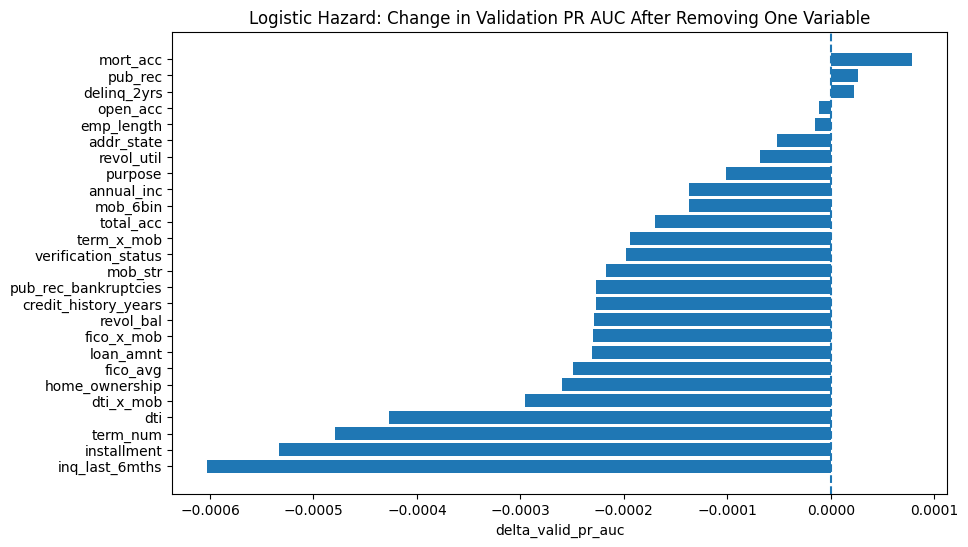

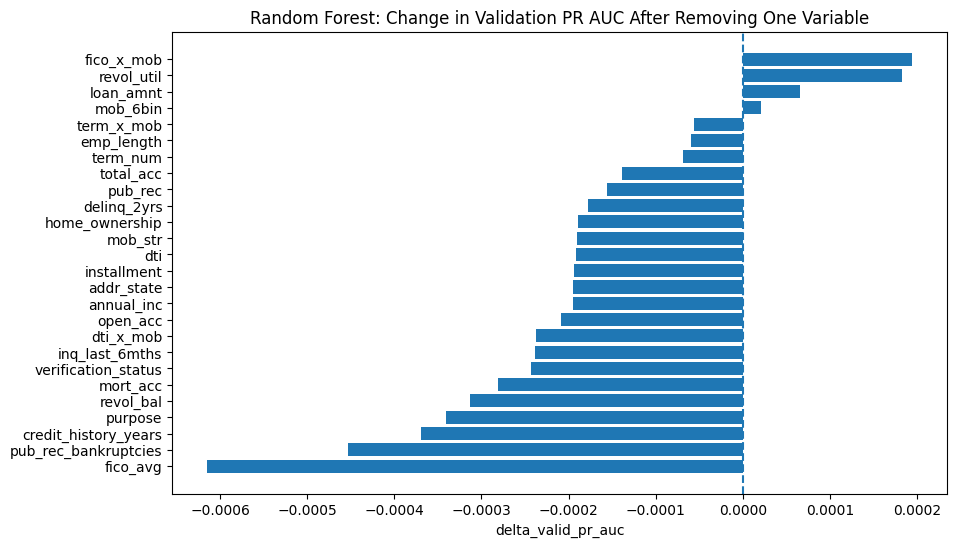

In [ ]:
plot_group_removal(
    single_logit_results,
    "delta_valid_pr_auc",
    "Logistic Hazard: Change in Validation PR AUC After Removing One Variable"
)

plot_group_removal(
    single_rf_results,
    "delta_valid_pr_auc",
    "Random Forest: Change in Validation PR AUC After Removing One Variable"
)

In [ ]:
def flag_removal_candidates(results_df, pr_tol=0.002, logloss_tol=0.005):
    out = results_df.copy()

    out["safe_to_remove"] = (
        (out["delta_valid_pr_auc"] >= -pr_tol) &
        (out["delta_valid_logloss"] <= logloss_tol)
    )

    return out.sort_values(
        ["safe_to_remove", "delta_valid_pr_auc", "delta_valid_logloss"],
        ascending=[False, False, True]
    )

flagged_logit = flag_removal_candidates(grouped_logit_results)
flagged_rf = flag_removal_candidates(grouped_rf_results)

flagged_logit[[
    "removed_group", "removed_vars",
    "delta_valid_pr_auc", "delta_valid_roc_auc",
    "delta_valid_logloss", "safe_to_remove"
]]

,removed_group,removed_vars,delta_valid_pr_auc,delta_valid_roc_auc,delta_valid_logloss,safe_to_remove
0,capacity_depth,"total_acc, mort_acc, credit_history_years",-0.000052,-0.000946,0.000033,True
1,purpose_state,"purpose, addr_state",-0.000064,-0.002146,0.000023,True
2,employment_home,"emp_length, home_ownership",-0.000070,-0.000404,0.000014,True
3,time_interactions,"fico_x_mob, term_x_mob, dti_x_mob",-0.000156,-0.001340,0.000027,True
4,utilization_balance,"revol_bal, revol_util",-0.000171,-0.002192,0.000042,True
5,income_verification,"annual_inc, verification_status",-0.000176,-0.002078,-0.000004,True
6,accounts_public,"open_acc, pub_rec, pub_rec_bankruptcies",-0.000223,-0.002675,0.000048,True
7,credit_quality,"fico_avg, dti",-0.000433,-0.010802,0.000202,True
8,delinq_inquiry,"delinq_2yrs, inq_last_6mths",-0.000603,-0.004724,0.000064,True
9,loan_size_terms,"loan_amnt, term_num, installment",-0.000791,-0.010124,0.000150,True


In [ ]:
groups_to_remove_logit = flagged_logit.loc[
    flagged_logit["safe_to_remove"], "removed_group"
].tolist()

groups_to_remove_logit

['capacity_depth',
 'purpose_state',
 'employment_home',
 'time_interactions',
 'utilization_balance',
 'income_verification',
 'accounts_public',
 'credit_quality',
 'delinq_inquiry',
 'loan_size_terms',
 'time_main']